# Defining Custom MCDA Methods

VISTA can work with **any** callable that follows a simple interface — you don't have to pick from the built-in methods. This notebook shows three levels of integration:

1. **A plain function** — the fastest way to prototype a new idea.
2. **A function with tuneable parameters** — compare behaviour under different settings.
3. **A full `MethodAdapter`** — register the method so it is discoverable by name.

In [1]:
%matplotlib inline

In [2]:
import numpy as np
from mcda_vista import generate_vista, plot_vista, plot_vista_comparison, Relation, VistaResult
from mcda_vista.methods import register_method, list_methods, get_method
from mcda_vista.methods.base import MethodAdapter

## 1. Simple Custom Callable

The minimal interface that `generate_vista` accepts is:

```python
def my_method(dataset: np.ndarray, weights: np.ndarray, **params) -> Relation:
    ...
```

where:

- `dataset[0]` — the **reference** alternative (1-D array of criterion values),
- `dataset[1]` — the **test point** being evaluated,
- `weights` — the criteria weight vector,
- `**params` — any extra keyword arguments forwarded from `generate_vista()`.

The function must return one of `Relation.BETTER`, `Relation.WORSE`, `Relation.INDIFFERENT`, or `Relation.INCOMPARABLE`.

Below is a simple weighted-sum comparison: compute a score for each alternative and compare them.

In [3]:
def simple_weighted_sum(dataset, weights, **params):
    """Weighted-sum comparison with an indifference threshold."""
    delta = params.get("delta", 0.05)
    score_ref = np.dot(dataset[0], weights)
    score_test = np.dot(dataset[1], weights)
    diff = score_test - score_ref
    if abs(diff) < delta:
        return Relation.INDIFFERENT
    return Relation.BETTER if diff > 0 else Relation.WORSE

VISTA (simple_weighted_sum):   0%|          | 0/2601 [00:00<?, ?pt/s]

VISTA (simple_weighted_sum): 100%|██████████| 2601/2601 [00:00<00:00, 235883.69pt/s]


C:\Users\dariu\AppData\Local\Temp\ipykernel_24440\554979843.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


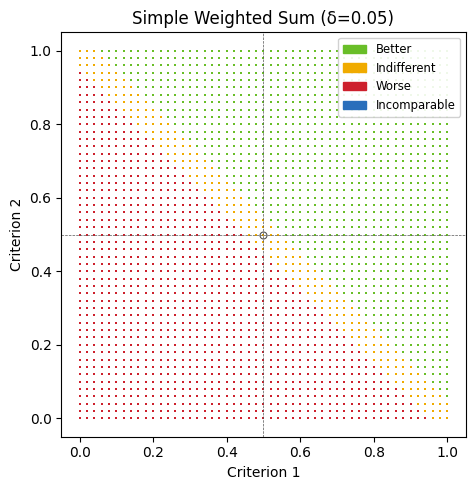

In [4]:
result_wsum = generate_vista(simple_weighted_sum, resolution=51, delta=0.05)

fig = plot_vista(result_wsum, title="Simple Weighted Sum (δ=0.05)")
fig.show()

That's it — any function matching the interface works out of the box.

## 2. Wrapping a pyDecision Method

pyDecision ships **50+ MCDA algorithms**, but mcda-vista registers only a subset as
built-in adapters. To use any other pyDecision method you just write a thin wrapper
function — no forking, no class, no registration needed.

The recipe:

1. **Import** the pyDecision function.
2. **Call it** with `graph=False, verbose=False` and criterion types set to `"max"` (VISTA
   data lives in normalised \[0, 1\] space where higher is always better).
3. **Convert** the numeric output to a `Relation` using a helper from `mcda_vista.converters`.

Below we wrap **COPRAS** (Complex Proportional Assessment), which is not registered
in mcda-vista.

In [ ]:
from pyDecision.algorithm import copras_method
from mcda_vista.converters import relation_from_aggregates


def copras_vista(dataset, weights, **params):
    """COPRAS wrapper — not registered, just a plain function."""
    delta = params.get("delta", 0.10)
    n = dataset.shape[1]
    c_types = ["max"] * n
    result = copras_method(dataset, weights, c_types, graph=False, verbose=False)
    # result shape (m, 2): column 0 = alt index, column 1 = utility degree
    return relation_from_aggregates(result[0, 1], result[1, 1], delta)

In [ ]:
result_copras = generate_vista(copras_vista, resolution=51, delta=0.10)
result_topsis = generate_vista("topsis", resolution=51, delta=0.10)

result_copras.method_name = "COPRAS (custom)"

fig = plot_vista_comparison([result_copras, result_topsis], ncols=2)
fig.show()

The wrapper is six lines of code. The key ingredient is picking the right **converter**
for the output format of your pyDecision method:

| Converter | When to use | Example methods |
|---|---|---|
| `relation_from_aggregates(score_ref, score_test, delta)` | Utility / closeness scores | COPRAS, TOPSIS, SAW, EDAS, MOORA |
| `relation_from_ranks(rank_ref, rank_test)` | Rank-based output | Borda, VIKOR |
| `relation_from_credibilities(c12, c21, threshold)` | Outranking credibility indices | ELECTRE |

Peek at the built-in adapters in `src/mcda_vista/methods/` for more real-world examples.

## 3. Wrapping a Fuzzy pyDecision Method

mcda-vista ships ready-made fuzzy wrappers in `mcda_vista.fuzzy_utils` for six
methods (Fuzzy TOPSIS, VIKOR, MOORA, WASPAS, EDAS, COPRAS). For any **other** fuzzy
method in pyDecision you can build your own wrapper using the same fuzzification helpers.

The extra parameters compared to a crisp wrapper:

- **`spread`** — half-width of the triangular fuzzy number around each crisp value.
  `spread=0` degenerates to crisp; larger values model greater uncertainty.
- **`skew`** — asymmetry factor in \[-1, 1\]. `0` = symmetric triangle,
  positive = right-skewed (optimistic), negative = left-skewed (pessimistic).

Below we wrap **Fuzzy ARAS**, which has no pre-built wrapper in `fuzzy_utils`.

In [ ]:
from pyDecision.algorithm import fuzzy_aras_method
from mcda_vista.fuzzy_utils import fuzzify_matrix, fuzzify_weights


def fuzzy_aras_vista(dataset, weights, **params):
    """Fuzzy ARAS wrapper — not in fuzzy_utils, built from scratch."""
    spread = params.get("spread", 0.10)
    skew = params.get("skew", 0.0)
    delta = params.get("delta", 0.10)
    n = dataset.shape[1]
    c_types = ["max"] * n
    f_dataset = fuzzify_matrix(dataset, spread, skew)
    f_weights = fuzzify_weights(weights, spread, skew)
    scores = fuzzy_aras_method(
        dataset=f_dataset, weights=f_weights,
        criterion_type=c_types, graph=False, verbose=False,
    )
    return relation_from_aggregates(scores[0], scores[1], delta)

In [ ]:
spreads = [0.0, 0.10, 0.20, 0.30]

results_spread = []
for s in spreads:
    r = generate_vista(fuzzy_aras_vista, resolution=51, spread=s, delta=0.10)
    r.method_name = f"Fuzzy ARAS  spread={s}"
    results_spread.append(r)

fig = plot_vista_comparison(results_spread, ncols=4)
fig.show()

At `spread=0` the fuzzy wrapper degenerates to the crisp case. As `spread` grows,
the indifferent region widens because fuzzy score distributions overlap more.

See `notebooks/11_fuzzy_methods.ipynb` for a deeper exploration of spread and skew
effects across multiple fuzzy methods.

## 4. Custom Method with Parameters

Extra keyword arguments passed to `generate_vista()` are forwarded straight to your callable, so you can expose tuneable parameters with no extra plumbing.

The method below uses the **Chebyshev distance** (L∞ norm) to the ideal point `[1, 1, …]`. A lower distance means a better alternative.

In [5]:
def chebyshev_method(dataset, weights, **params):
    """Compare alternatives by weighted Chebyshev distance to the ideal."""
    delta = params.get("delta", 0.05)
    ref, test = dataset[0], dataset[1]
    dist_ref = np.max(np.abs(weights * (1.0 - ref)))
    dist_test = np.max(np.abs(weights * (1.0 - test)))
    diff = dist_ref - dist_test  # lower distance = better
    if abs(diff) < delta:
        return Relation.INDIFFERENT
    return Relation.BETTER if diff > 0 else Relation.WORSE

Generate VISTAs for several delta values and compare them side by side:

VISTA (chebyshev_method):   0%|          | 0/2601 [00:00<?, ?pt/s]

VISTA (chebyshev_method): 100%|██████████| 2601/2601 [00:00<00:00, 82538.68pt/s]

VISTA (chebyshev_method):   0%|          | 0/2601 [00:00<?, ?pt/s]

VISTA (chebyshev_method): 100%|██████████| 2601/2601 [00:00<00:00, 76501.79pt/s]

VISTA (chebyshev_method):   0%|          | 0/2601 [00:00<?, ?pt/s]

VISTA (chebyshev_method): 100%|██████████| 2601/2601 [00:00<00:00, 83910.60pt/s]

VISTA (chebyshev_method):   0%|          | 0/2601 [00:00<?, ?pt/s]

VISTA (chebyshev_method): 100%|██████████| 2601/2601 [00:00<00:00, 62600.83pt/s]

C:\Users\dariu\AppData\Local\Temp\ipykernel_24440\657245774.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


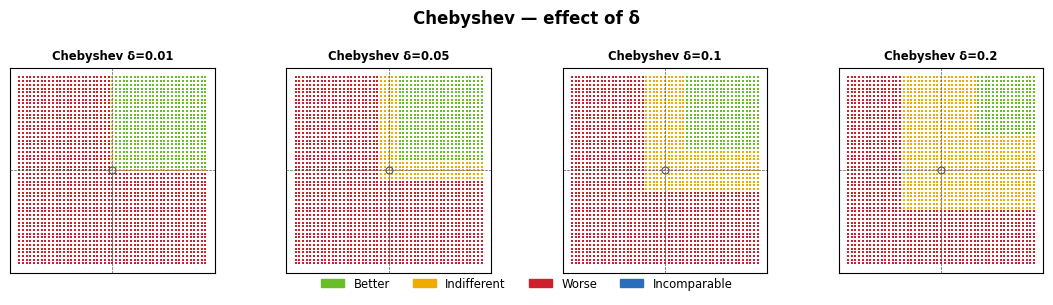

In [6]:
deltas = [0.01, 0.05, 0.10, 0.20]

results_cheb = []
for d in deltas:
    r = generate_vista(chebyshev_method, resolution=51, delta=d)
    # Override method_name for subplot titles
    r.method_name = f"Chebyshev δ={d}"
    results_cheb.append(r)

fig = plot_vista_comparison(results_cheb, ncols=4, title="Chebyshev — effect of δ")
fig.show()

As δ grows, the indifferent region widens — exactly what you'd expect from a threshold parameter.

## 5. Registering as a MethodAdapter

For methods you intend to reuse across experiments, wrap them in a class that satisfies the `MethodAdapter` protocol and decorate it with `@register_method`. This adds:

- **Discoverability** — the method shows up in `list_methods()` and can be looked up by name.
- **Default parameters** — `default_params()` provides sensible defaults.
- **Parameter metadata** — `param_space()` describes ranges and labels for UI sliders and parameter sweeps.

In [7]:
@register_method("chebyshev")
class ChebyshevAdapter:
    name = "chebyshev"
    display_name = "Chebyshev"

    def evaluate(self, dataset, weights, **params):
        delta = params.get("delta", 0.05)
        ref, test = dataset[0], dataset[1]
        dist_ref = np.max(np.abs(weights * (1.0 - ref)))
        dist_test = np.max(np.abs(weights * (1.0 - test)))
        diff = dist_ref - dist_test
        if abs(diff) < delta:
            return Relation.INDIFFERENT
        return Relation.BETTER if diff > 0 else Relation.WORSE

    def default_params(self):
        return {"delta": 0.05}

    def param_space(self):
        return {
            "delta": {
                "min": 0.0,
                "max": 0.5,
                "default": 0.05,
                "step": 0.01,
                "label": "δ (indifference)",
            },
        }

In [8]:
# Verify registration
print("Registered:", "chebyshev" in list_methods())

adapter = get_method("chebyshev")
print("Display name:", adapter.display_name)
print("Defaults:    ", adapter.default_params())
print("Param space: ", adapter.param_space())

Registered: True
Display name: Chebyshev
Defaults:     {'delta': 0.05}
Param space:  {'delta': {'min': 0.0, 'max': 0.5, 'default': 0.05, 'step': 0.01, 'label': 'δ (indifference)'}}


VISTA (chebyshev):   0%|          | 0/2601 [00:00<?, ?pt/s]

VISTA (chebyshev): 100%|██████████| 2601/2601 [00:00<00:00, 92823.71pt/s]


C:\Users\dariu\AppData\Local\Temp\ipykernel_24440\2166814773.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


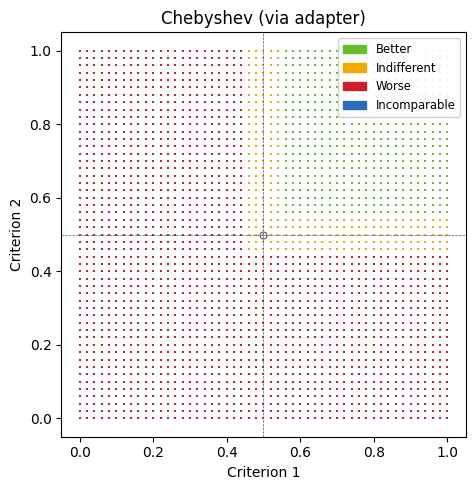

In [9]:
# Now usable by name, just like built-in methods
result_adapter = generate_vista("chebyshev", resolution=51)

fig = plot_vista(result_adapter, title="Chebyshev (via adapter)")
fig.show()

## 6. Comparing Custom vs Built-in Methods

Once registered, custom methods slot seamlessly into `plot_vista_comparison` alongside built-in ones:

VISTA (chebyshev):   0%|          | 0/2601 [00:00<?, ?pt/s]

VISTA (chebyshev): 100%|██████████| 2601/2601 [00:00<00:00, 96331.81pt/s]

VISTA (topsis):   0%|          | 0/2601 [00:00<?, ?pt/s]

VISTA (topsis):  69%|██████▉   | 1804/2601 [00:00<00:00, 17876.23pt/s]

VISTA (topsis): 100%|██████████| 2601/2601 [00:00<00:00, 18588.81pt/s]

VISTA (saw):   0%|          | 0/2601 [00:00<?, ?pt/s]

VISTA (saw):  93%|█████████▎| 2409/2601 [00:00<00:00, 24000.02pt/s]

VISTA (saw): 100%|██████████| 2601/2601 [00:00<00:00, 23644.40pt/s]

C:\Users\dariu\AppData\Local\Temp\ipykernel_24440\2757966593.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


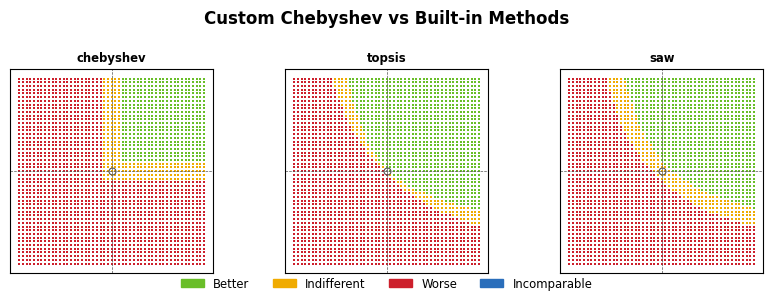

In [10]:
methods = ["chebyshev", "topsis", "saw"]

results_cmp = [generate_vista(m, resolution=51) for m in methods]

fig = plot_vista_comparison(
    results_cmp,
    ncols=3,
    title="Custom Chebyshev vs Built-in Methods",
)
fig.show()

## Summary

| Integration level | What you write | What you get |
|---|---|---|
| **Plain callable** | `def f(dataset, weights, **params) -> Relation` | Works with `generate_vista(f, ...)` immediately |
| **pyDecision wrapper** | Import pyDecision function + thin wrapper + converter | Works with any of pyDecision's 50+ algorithms; no fork or class needed |
| **Fuzzy pyDecision wrapper** | Fuzzification helpers + fuzzy method call | Exposes `spread`/`skew` parameters; see `fuzzy_utils` for built-in wrappers |
| **MethodAdapter class** | A class with `evaluate`, `default_params`, `param_space` | Discoverable by name via `generate_vista("key", ...)`, parameter metadata for sweeps and UIs |

Start with a plain function while prototyping. When the method is stable, promote it to a `MethodAdapter` and register it.